In [18]:
# Librerie per Reddit API
import praw

# Analisi dati
import pandas as pd

# Analisi testuale
from textblob import TextBlob

# Costruzione grafo
import networkx as nx

# Visualizzazione
import matplotlib.pyplot as plt

# Utility
from collections import defaultdict
import re
import numpy as np
from itertools import combinations
from tqdm import tqdm
from networkx.algorithms.community import greedy_modularity_communities

In [ ]:
import praw
import pandas as pd

# Config Reddit API (già fatto)
reddit = praw.Reddit(
    client_id="0PYPKuhHGg4cXmmjBFcW8Q",
    client_secret="5aXgtCQgesKU-5Yj2ItqQ2Jio3-okQ",
    user_agent="script:AutoProject:v1.0 (by u/DueInformation2883)"
)

# Specifica il subreddit che stai analizzando
subreddit = reddit.subreddit("electricvehicles")  # Cambia nome se necessario

# Estrai i commenti da più post
comments_data = []
for submission in subreddit.hot(limit=50):  # Puoi aumentare a 100 se vuoi
    submission.comments.replace_more(limit=0)
    for comment in submission.comments.list():
        comments_data.append(comment.body)

# Crea DataFrame e salva in CSV
df_comments = pd.DataFrame(comments_data, columns=["text"])
df_comments.dropna(inplace=True)  # rimuove eventuali righe vuote
df_comments.to_csv("comments.csv", index=False)
print(f"✅ Salvati {len(df_comments)} commenti in comments.csv")


Why I sold my Tesla Model 3 Performance & went back to gas
I'm getting rid of my 2021 Tesla Model 3 Long Range after 6 months of ownership. Here's why:
The tesla V11 Update is Starting to Make me Regret my Model 3 Purchase
Does it bother anybody else that the upcoming Tesla Cybertruck will have (top model) sub-3 second 0-60 acceleration but the handling and braking of, well, a 4+ ton truck??
Rich Rebuilds: Tesla wanted $16,000 to fix this NEW Model 3, we did it for $700! The importance of Right to REPAIR!


In [8]:
electric_models = [
    "Tesla Model 3",
    "Nissan Leaf",
    "Polestar 2"
]

gas_models = [
    "BMW Serie 3",
    "Volkswagen Golf GTI",
    "Ford Focus ST"
]

model_list = [(model, "elettrica") for model in electric_models] + \
             [(model, "benzina") for model in gas_models]

subreddits = ["cars", "whatcarshouldIbuy", "TeslaMotors"]

posts_data = []

for model, tipo in tqdm(model_list, desc="Modelli analizzati"):
    for subreddit_name in subreddits:
        try:
            subreddit = reddit.subreddit(subreddit_name)
            for post in subreddit.search(model, limit=20):
                post.comments.replace_more(limit=0)  # Rimuove i "MoreComments"
                commenters = [
                    comment.author.name
                    for comment in post.comments
                    if comment.author and comment.author.name != "AutoModerator"
                ]

                posts_data.append({
                    "post_id": post.id,
                    "title": post.title,
                    "model": model,
                    "tipo": tipo,
                    "subreddit": subreddit_name,
                    "commenters": commenters
                })
        except Exception as e:
            print(f"Errore con {model} in r/{subreddit_name}: {e}")

Modelli analizzati: 100%|██████████| 6/6 [07:32<00:00, 75.39s/it] 


In [10]:
# Numero di post raccolti
print(f"Totale post raccolti: {len(posts_data)}")

# Mostra i primi 2 post
for post in posts_data[:2]:
    print(f"\nTitolo: {post['title']}")
    print(f"Modello: {post['model']} | Tipo: {post['tipo']} | Subreddit: {post['subreddit']}")
    print(f"Numero commenti: {len(post['commenters'])}")
    print(f"Utenti: {post['commenters'][:5]}")  # Mostra solo i primi 5 utenti


Totale post raccolti: 344

Titolo: Why I sold my Tesla Model 3 Performance & went back to gas
Modello: Tesla Model 3 | Tipo: elettrica | Subreddit: cars
Numero commenti: 68
Utenti: ['henryrobertsam', 'ice445', 'sfbiker999', 'hutacars', 'bezelbubba']

Titolo: I'm getting rid of my 2021 Tesla Model 3 Long Range after 6 months of ownership. Here's why:
Modello: Tesla Model 3 | Tipo: elettrica | Subreddit: cars
Numero commenti: 77
Utenti: ['AlrightAlbatross', '3p1cBm4n9669', 'gHHqdm5a4UySnUFM', 'bigguy14433', 'Nukedogger86']


In [13]:
# Inizializziamo il grafo
G = nx.Graph()

# Aggiungiamo i nodi (ogni post = nodo)
for post in posts_data:
    G.add_node(
        post["post_id"],
        title=post["title"],
        model=post["model"],
        tipo=post["tipo"],
        subreddit=post["subreddit"],
        commenters=set(post["commenters"])  # lo teniamo per il matching utenti
    )

# Connettiamo i nodi (post) se condividono almeno 1 utente
post_ids = list(G.nodes())

# Creiamo le combinazioni di tutti i post (ogni coppia)
for post1_id, post2_id in combinations(post_ids, 2):
    commenters1 = G.nodes[post1_id]["commenters"]
    commenters2 = G.nodes[post2_id]["commenters"]

    # Intersezione utenti
    utenti_comuni = commenters1 & commenters2
    if len(utenti_comuni) > 0:
        G.add_edge(post1_id, post2_id, weight=len(utenti_comuni))

# Pulizia: rimuoviamo l'attributo temporaneo 'commenters'
for n in G.nodes:
    del G.nodes[n]["commenters"]


In [14]:
print(f"Numero nodi (post): {G.number_of_nodes()}")
print(f"Numero archi (connessioni tra post): {G.number_of_edges()}")

# Esempio: mostra 3 nodi con attributi
for n in list(G.nodes(data=True))[:3]:
    print(n)


Numero nodi (post): 341
Numero archi (connessioni tra post): 2994
('rshvy0', {'title': 'Why I sold my Tesla Model 3 Performance & went back to gas', 'model': 'Tesla Model 3', 'tipo': 'elettrica', 'subreddit': 'cars'})
('sdfxdq', {'title': "I'm getting rid of my 2021 Tesla Model 3 Long Range after 6 months of ownership. Here's why:", 'model': 'Tesla Model 3', 'tipo': 'elettrica', 'subreddit': 'cars'})
('rwpnpf', {'title': 'The tesla V11 Update is Starting to Make me Regret my Model 3 Purchase', 'model': 'Tesla Model 3', 'tipo': 'elettrica', 'subreddit': 'cars'})


In [15]:
print("Numero nodi:", G.number_of_nodes())
print("Numero archi:", G.number_of_edges())

degrees = [deg for _, deg in G.degree()]
print(f"Grado medio: {sum(degrees) / len(degrees):.2f}")
print(f"Grado massimo: {max(degrees)}")


Numero nodi: 341
Numero archi: 2994
Grado medio: 17.56
Grado massimo: 67


In [19]:

# Trova le community (lista di set di nodi)
communities = list(greedy_modularity_communities(G))

# Assegna un numero di community a ciascun nodo
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

# Aggiungiamolo come attributo al grafo
nx.set_node_attributes(G, community_map, "community")

print(f"Numero di community trovate: {len(communities)}")


Numero di community trovate: 49


In [20]:
# Assortatività rispetto all'attributo "tipo"
assort = nx.attribute_assortativity_coefficient(G, "tipo")
print(f"Assortatività per tipo di auto (elettrica/benzina): {assort:.2f}")


Assortatività per tipo di auto (elettrica/benzina): 0.10


In [22]:
nx.write_gexf(G, "reddit_auto_network.gexf")


In [1]:
import praw
from collections import defaultdict
import pandas as pd

# Config Reddit API
reddit = praw.Reddit(
    client_id="0PYPKuhHGg4cXmmjBFcW8Q",
    client_secret="5aXgtCQgesKU-5Yj2ItqQ2Jio3-okQ",
    user_agent="script:AutoProject:v1.0 (by u/DueInformation2883)"
)

electric_models = ["Tesla Model 3", "Nissan Leaf", "Polestar 2"]
gas_models = ["BMW Serie 3", "Volkswagen Golf GTI", "Ford Focus ST"]
model_list = [(model, "elettrica") for model in electric_models] + [(model, "benzina") for model in gas_models]
subreddits = ["cars", "whatcarshouldIbuy", "TeslaMotors"]

# Edge list
edges = defaultdict(int)

for model, tipo in model_list:
    for subreddit_name in subreddits:
        try:
            subreddit = reddit.subreddit(subreddit_name)
            for post in subreddit.search(model, limit=10):
                post.comments.replace_more(limit=0)
                commenters = [
                    comment.author.name
                    for comment in post.comments
                    if comment.author and comment.author.name != "AutoModerator"
                ]
                for i in range(len(commenters)):
                    for j in range(i + 1, len(commenters)):
                        u1, u2 = sorted([commenters[i], commenters[j]])
                        edges[(u1, u2)] += 1
        except Exception as e:
            print(f"Errore con {model} in r/{subreddit_name}: {e}")

# Salva edge list per me
df_edges = pd.DataFrame([{"source": u1, "target": u2, "weight": w} for (u1, u2), w in edges.items()])
df_edges.to_csv("edge_list.csv", index=False)


In [2]:
import networkx as nx
import pandas as pd

# Carica l'edge list (assicurati di avere questo CSV già salvato dal tuo progetto)
df_edges = pd.read_csv("edge_list.csv")

# Crea un grafo non orientato (o usa nx.DiGraph() se vuoi orientato)
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcolo della closeness centrality
print("Calcolo della closeness centrality in corso... può richiedere un po’ di tempo su reti grandi.")
closeness_centrality = nx.closeness_centrality(G)

# Converto in DataFrame
df_closeness = pd.DataFrame(closeness_centrality.items(), columns=["username", "closeness_centrality"])

# Ordina e mostra i top 15 (opzionale)
print(df_closeness.sort_values(by="closeness_centrality", ascending=False).head(15))

# Salva il file per inviarlo a me
df_closeness.to_csv("closeness_results.csv", index=False)
print("✅ closeness_results.csv salvato correttamente!")


Calcolo della closeness centrality in corso... può richiedere un po’ di tempo su reti grandi.
               username  closeness_centrality
319            Trades46              0.443824
398           VegaGT-VZ              0.425649
70     gHHqdm5a4UySnUFM              0.417017
2592        Yojimbo4133              0.416716
3              hutacars              0.415123
53                xdr01              0.411504
84              dissss0              0.410829
477             wip30ut              0.410536
687   Healthy_Block3036              0.409223
1554           Decronym              0.407255
512           imped4now              0.398407
658           jumpybean              0.398021
54          natesully33              0.397911
187            Fidget08              0.395561
3441           Bamfor07              0.395506
✅ closeness_results.csv salvato correttamente!


In [3]:
import pandas as pd
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

# STEP 1: Carica l'edge list
df_edges = pd.read_csv("edge_list.csv")

# STEP 2: Costruisci il grafo
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# STEP 3: Calcola tutte le centralità
print("▶️ Calcolo degree centrality...")
degree = nx.degree_centrality(G)

print("▶️ Calcolo closeness centrality...")
closeness = nx.closeness_centrality(G)

print("▶️ Calcolo betweenness centrality... (può richiedere tempo)")
betweenness = nx.betweenness_centrality(G, weight="weight")

# STEP 4: Community detection con greedy modularity
print("▶️ Community detection...")
communities = list(greedy_modularity_communities(G))
user_to_community = {}
for i, comm in enumerate(communities):
    for user in comm:
        user_to_community[user] = i

# STEP 5: Unisci tutto in un DataFrame
df_all_metrics = pd.DataFrame({
    "username": list(G.nodes()),
    "degree": [degree[u] for u in G.nodes()],
    "closeness": [closeness[u] for u in G.nodes()],
    "betweenness": [betweenness[u] for u in G.nodes()],
    "community": [user_to_community[u] for u in G.nodes()]
})

# STEP 6: Salva su file CSV
df_all_metrics.to_csv("tutte_metriche_reddit.csv", index=False)
print("✅ File 'tutte_metriche_reddit.csv' salvato correttamente!")


▶️ Calcolo degree centrality...
▶️ Calcolo closeness centrality...
▶️ Calcolo betweenness centrality... (può richiedere tempo)
▶️ Community detection...
✅ File 'tutte_metriche_reddit.csv' salvato correttamente!


In [4]:
total_posts = 0

for model, tipo in model_list:
    for subreddit_name in subreddits:
        subreddit = reddit.subreddit(subreddit_name)
        for post in subreddit.search(model, limit=10):
            total_posts += 1

print("Totale post raccolti:", total_posts)


Totale post raccolti: 180


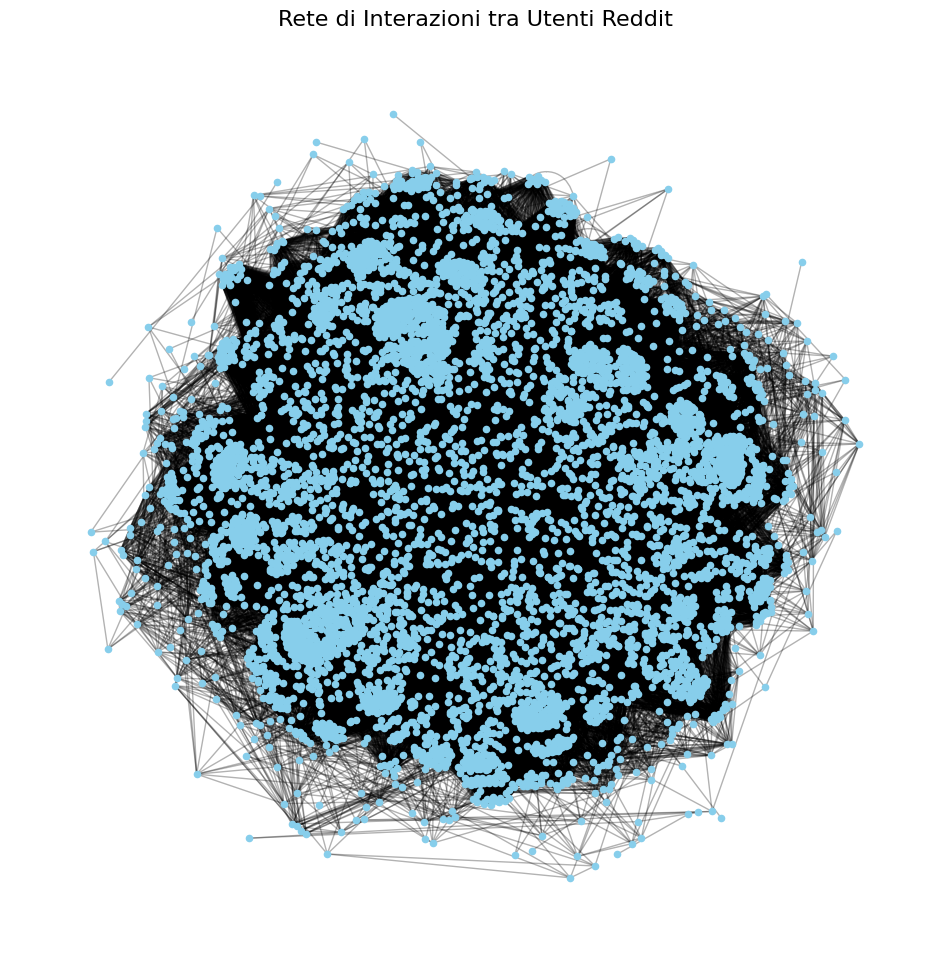

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# STEP 1: Carica o usa il DataFrame con le connessioni
df_edges = pd.read_csv("edge_list.csv")  # se non già caricato

# STEP 2: Crea il grafo
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# STEP 3: Crea layout e disegna il grafo
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15, iterations=20)  # layout con effetto 'esploso'
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='skyblue')
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.axis("off")
plt.title("Rete di Interazioni tra Utenti Reddit", fontsize=16)

# STEP 4: Salva l’immagine per la slide
plt.savefig("grafo_reddit_utenti.png", dpi=300, bbox_inches="tight")
plt.show()


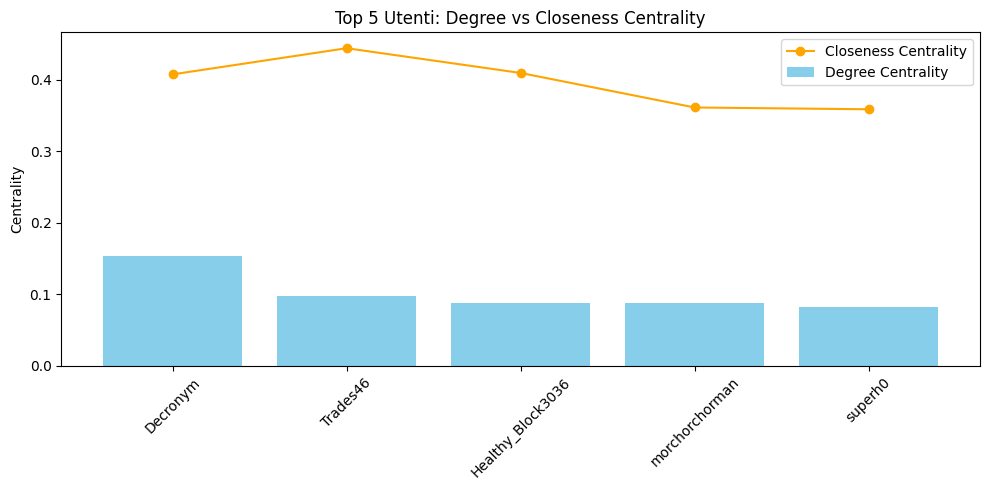

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica il file con le metriche, se non l'hai già fatto
df = pd.read_csv("tutte_metriche_reddit.csv")

# Ordina per Degree e prendi i top 5 utenti
top5_degree = df.sort_values(by="degree", ascending=False).head(5)
top5_closeness = df.sort_values(by="closeness", ascending=False).head(5)

# Crea il grafico comparativo
fig, ax = plt.subplots(figsize=(10, 5))

# Degree
ax.bar(top5_degree["username"], top5_degree["degree"], color='skyblue', label='Degree Centrality')

# Closeness (linea sovrapposta)
ax.plot(top5_degree["username"], top5_degree["closeness"], color='orange', marker='o', label='Closeness Centrality')

# Titoli e legenda
ax.set_title("Top 5 Utenti: Degree vs Closeness Centrality")
ax.set_ylabel("Centrality")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Salva l'immagine per la slide
plt.savefig("degree_closeness_comparison.png", dpi=300)
plt.show()


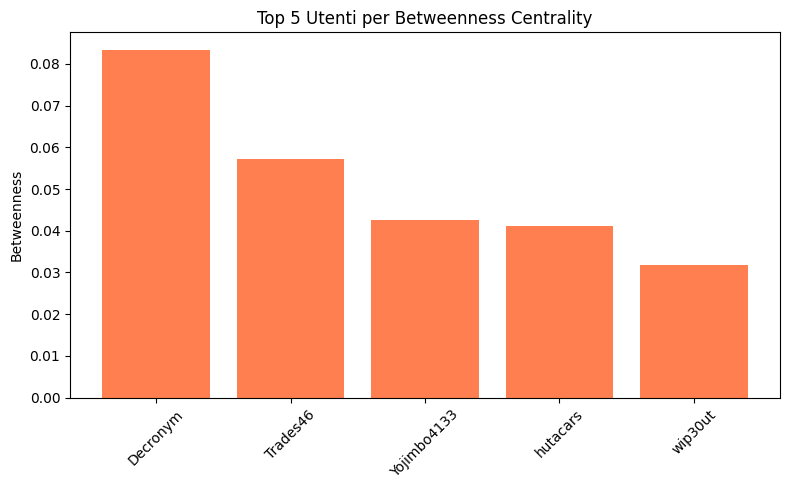

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica il dataset completo se non già fatto
df = pd.read_csv("tutte_metriche_reddit.csv")

# Ordina e prendi i top 5 per Betweenness
top5_betweenness = df.sort_values(by="betweenness", ascending=False).head(5)

# Crea il grafico
plt.figure(figsize=(8, 5))
plt.bar(top5_betweenness["username"], top5_betweenness["betweenness"], color='coral')
plt.title("Top 5 Utenti per Betweenness Centrality")
plt.ylabel("Betweenness")
plt.xticks(rotation=45)
plt.tight_layout()

# Salva immagine per slide
plt.savefig("betweenness_top5.png", dpi=300)
plt.show()


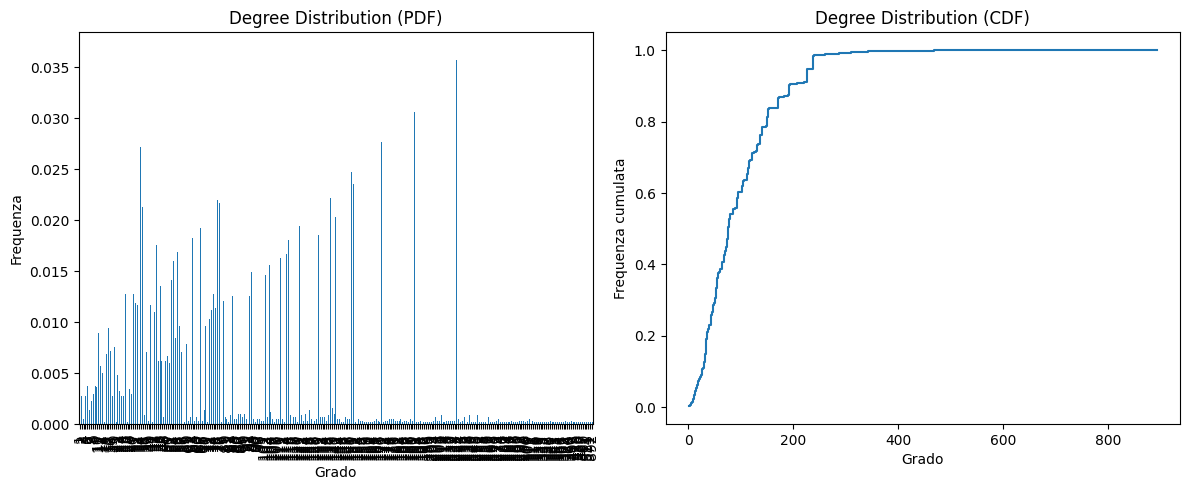

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Ricostruzione del grafo
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcolo dei gradi
degrees = [d for n, d in G.degree()]
degree_series = pd.Series(degrees)

# PDF (Probability Distribution Function)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
degree_series.value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title("Degree Distribution (PDF)")
plt.xlabel("Grado")
plt.ylabel("Frequenza")

# CDF (Cumulative Distribution Function)
plt.subplot(1, 2, 2)
degree_series.value_counts(normalize=True).sort_index().cumsum().plot(drawstyle='steps-post')
plt.title("Degree Distribution (CDF)")
plt.xlabel("Grado")
plt.ylabel("Frequenza cumulata")

# Salva immagine
plt.tight_layout()
plt.savefig("degree_distribution_pdf_cdf.png", dpi=300)
plt.show()


In [9]:
import pandas as pd
import networkx as nx
import numpy as np

# Carica la tua edge list
df_edges = pd.read_csv("edge_list.csv")

# Crea il grafo non orientato
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcoli base
order = G.number_of_edges()           # numero di archi
size = G.number_of_nodes()            # numero di nodi
degrees = [d for _, d in G.degree()]
avg_degree = np.mean(degrees)
std_dev = np.std(degrees)
med = np.median(degrees)
max_deg = np.max(degrees)
min_deg = np.min(degrees)
density = nx.density(G)

# Trova il nodo con grado massimo
degree_dict = dict(G.degree())
node_max = max(degree_dict.items(), key=lambda x: x[1])
# Secondo nodo più connesso (escludendo outlier)
sorted_degrees = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
node_second = sorted_degrees[1] if len(sorted_degrees) > 1 else ("-", "-")

# Stampa i risultati
print(f"Network order (edges): {order}")
print(f"Network size (nodes): {size}")
print(f"Average Degree: {avg_degree}")
print(f"Median: {med}")
print(f"Max degree: {max_deg}")
print(f"Min degree: {min_deg}")
print(f"Standard deviation: {std_dev}")
print(f"Density: {density:.8f}")
print(f"Node with max degree: {node_max}")
print(f"Node with max degree except {node_max[0]}: {node_second}")


Network order (edges): 279320
Network size (nodes): 5823
Average Degree: 95.93680233556586
Median: 76.0
Max degree: 892
Min degree: 1
Standard deviation: 68.93837982944198
Density: 0.01647832
Node with max degree: ('Decronym', 892)
Node with max degree except Decronym: ('Trades46', 571)


In [10]:
# Clustering coefficient medio
clustering_avg = nx.average_clustering(G)

# Transitivity (triangoli globali / triple connesse)
transitivity = nx.transitivity(G)

print(f"Average Clustering Coefficient: {clustering_avg:.4f}")
print(f"Transitivity: {transitivity:.4f}")


Average Clustering Coefficient: 0.9556
Transitivity: 0.8905


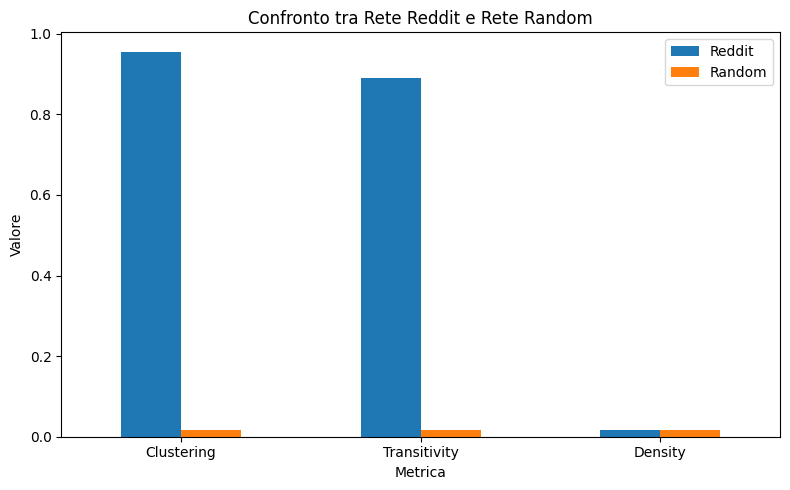

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Crea grafo Reddit (se non già creato)
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcolo metriche della rete Reddit
reddit_clustering = nx.average_clustering(G)
reddit_transitivity = nx.transitivity(G)
reddit_density = nx.density(G)

# Genera rete random con stessi nodi e archi
n = G.number_of_nodes()
m = G.number_of_edges()
G_random = nx.gnm_random_graph(n, m)

# Calcolo metriche della rete random
rand_clustering = nx.average_clustering(G_random)
rand_transitivity = nx.transitivity(G_random)
rand_density = nx.density(G_random)

# Crea DataFrame per confronto
df_compare = pd.DataFrame({
    "Metrica": ["Clustering", "Transitivity", "Density"],
    "Reddit": [reddit_clustering, reddit_transitivity, reddit_density],
    "Random": [rand_clustering, rand_transitivity, rand_density]
})

# Grafico a barre
df_compare.set_index("Metrica").plot(kind="bar", figsize=(8, 5), color=["#1f77b4", "#ff7f0e"])
plt.title("Confronto tra Rete Reddit e Rete Random")
plt.ylabel("Valore")
plt.xticks(rotation=0)
plt.tight_layout()

# Salva immagine
plt.savefig("confronto_reddit_random.png", dpi=300)
plt.show()


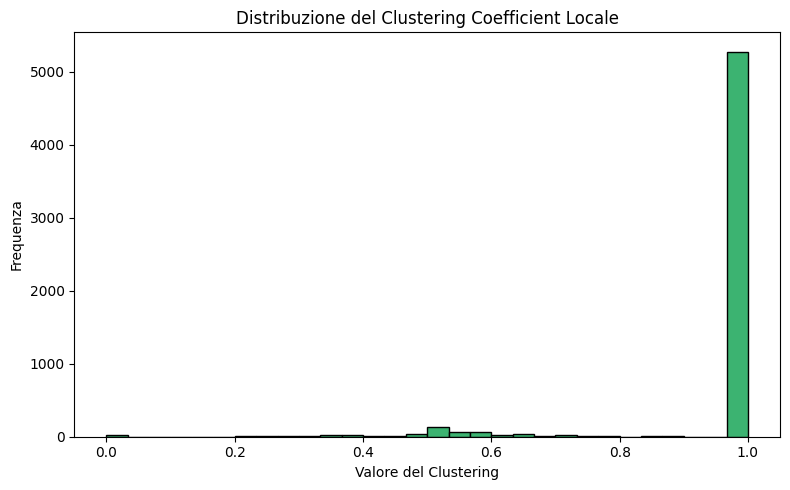

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Crea o carica il grafo Reddit
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcola i clustering locali
clustering_dict = nx.clustering(G)
clustering_values = list(clustering_dict.values())

# Istogramma
plt.figure(figsize=(8, 5))
plt.hist(clustering_values, bins=30, color='mediumseagreen', edgecolor='black')
plt.title("Distribuzione del Clustering Coefficient Locale")
plt.xlabel("Valore del Clustering")
plt.ylabel("Frequenza")
plt.tight_layout()

# Salva immagine
plt.savefig("distribuzione_clustering_locale.png", dpi=300)
plt.show()


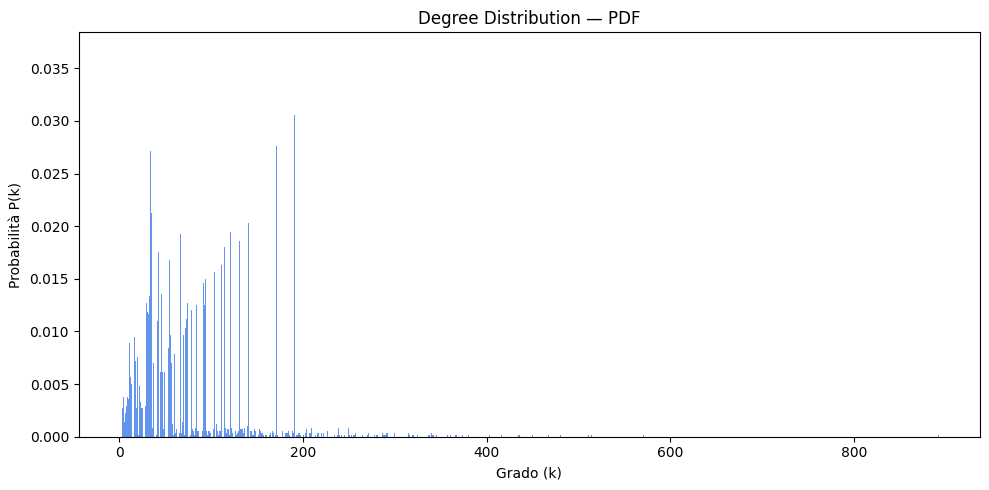

In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Crea grafo (se non già fatto)
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcola grado per ogni nodo
degrees = [d for _, d in G.degree()]

# Conta quanti nodi hanno ciascun grado
degree_series = pd.Series(degrees)
pdf = degree_series.value_counts(normalize=True).sort_index()

# Grafico PDF
plt.figure(figsize=(10, 5))
plt.bar(pdf.index, pdf.values, color='cornflowerblue')
plt.title("Degree Distribution — PDF")
plt.xlabel("Grado (k)")
plt.ylabel("Probabilità P(k)")
plt.tight_layout()

# Salva il grafico
plt.savefig("degree_distribution_pdf.png", dpi=300)
plt.show()


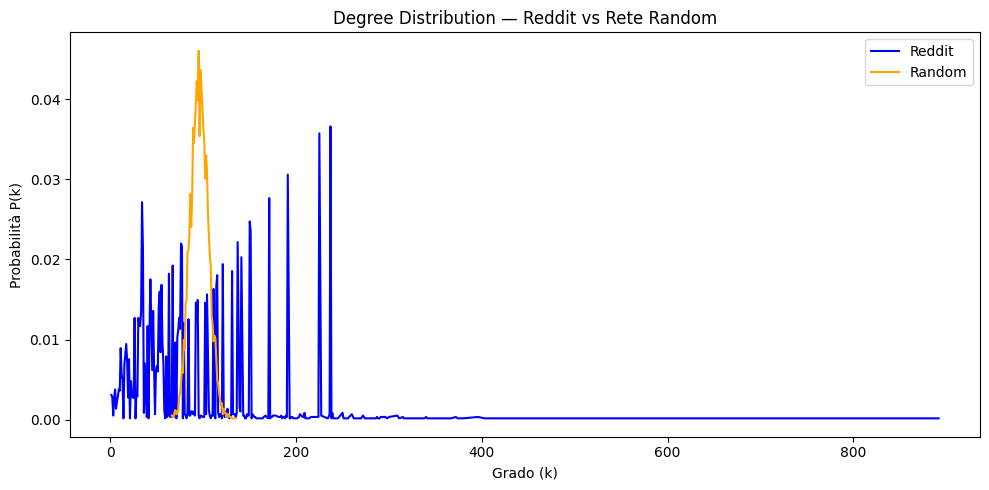

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

# Crea il grafo Reddit (se non già fatto)
df_edges = pd.read_csv("edge_list.csv")
G_reddit = nx.Graph()
for _, row in df_edges.iterrows():
    G_reddit.add_edge(row["source"], row["target"], weight=row["weight"])

# Crea la rete random equivalente (Erdős–Rényi)
n = G_reddit.number_of_nodes()
p = nx.density(G_reddit)
G_random = nx.erdos_renyi_graph(n=n, p=p)

# Calcola degree distribution normalizzata
def get_pdf(G):
    degrees = [d for _, d in G.degree()]
    degree_series = pd.Series(degrees)
    pdf = degree_series.value_counts(normalize=True).sort_index()
    return pdf

pdf_reddit = get_pdf(G_reddit)
pdf_random = get_pdf(G_random)

# Grafico comparativo
plt.figure(figsize=(10, 5))
plt.plot(pdf_reddit.index, pdf_reddit.values, label="Reddit", color="blue")
plt.plot(pdf_random.index, pdf_random.values, label="Random", color="orange")
plt.xlabel("Grado (k)")
plt.ylabel("Probabilità P(k)")
plt.title("Degree Distribution — Reddit vs Rete Random")
plt.legend()
plt.tight_layout()

# Salva immagine
plt.savefig("confronto_degree_distribution.png", dpi=300)
plt.show()


In [15]:
import networkx as nx
import pandas as pd

# Costruzione del grafo (se non ancora fatto)
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Trova tutte le componenti connesse
components = list(nx.connected_components(G))

# Ordina per dimensione
components_sizes = [len(c) for c in components]
components_sizes.sort(reverse=True)

# Numero totale
num_components = len(components)
largest = components_sizes[0]
second_largest = components_sizes[1] if len(components_sizes) > 1 else None

# Output
print(f"Numero totale di componenti connesse: {num_components}")
print(f"Dimensione della componente principale: {largest}")
if second_largest:
    print(f"Seconda più grande componente: {second_largest}")


Numero totale di componenti connesse: 13
Dimensione della componente principale: 5791
Seconda più grande componente: 5


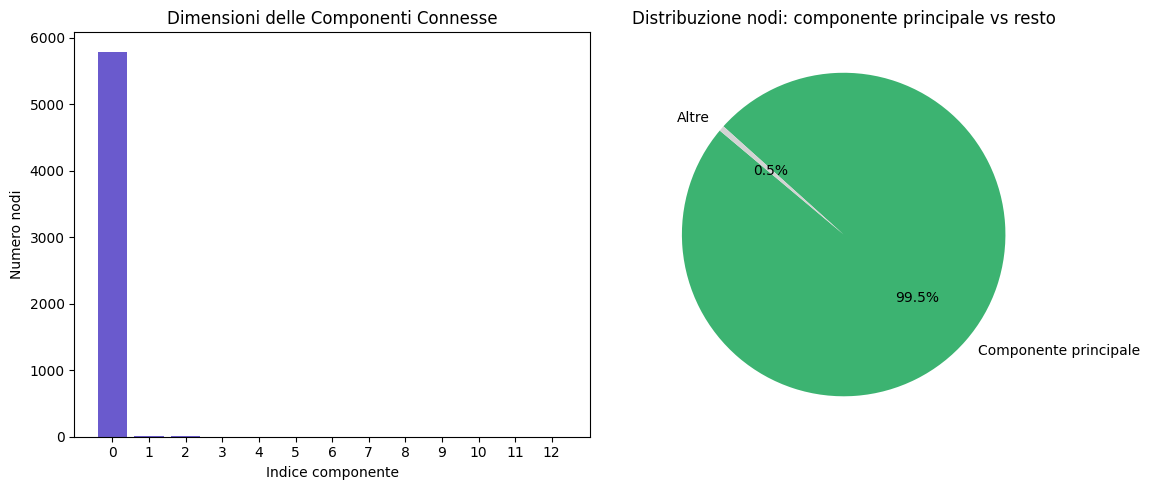

In [16]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Crea il grafo (non orientato)
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcola le componenti connesse
components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
component_sizes.sort(reverse=True)

# Grafico 1 – Barre: Top componenti per dimensione
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(len(component_sizes)), component_sizes, color="slateblue")
plt.title("Dimensioni delle Componenti Connesse")
plt.xlabel("Indice componente")
plt.ylabel("Numero nodi")
plt.xticks(range(len(component_sizes)))

# Grafico 2 – Torta: percentuale della componente principale
labels = ['Componente principale', 'Altre']
sizes = [component_sizes[0], sum(component_sizes[1:])]
colors = ['mediumseagreen', 'lightgray']

plt.subplot(1, 2, 2)
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Distribuzione nodi: componente principale vs resto")

# Salva immagine
plt.tight_layout()
plt.savefig("connected_components_comparison.png", dpi=300)
plt.show()


C:\Users\feder\AppData\Local\Temp\ipykernel_27720\3892382215.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


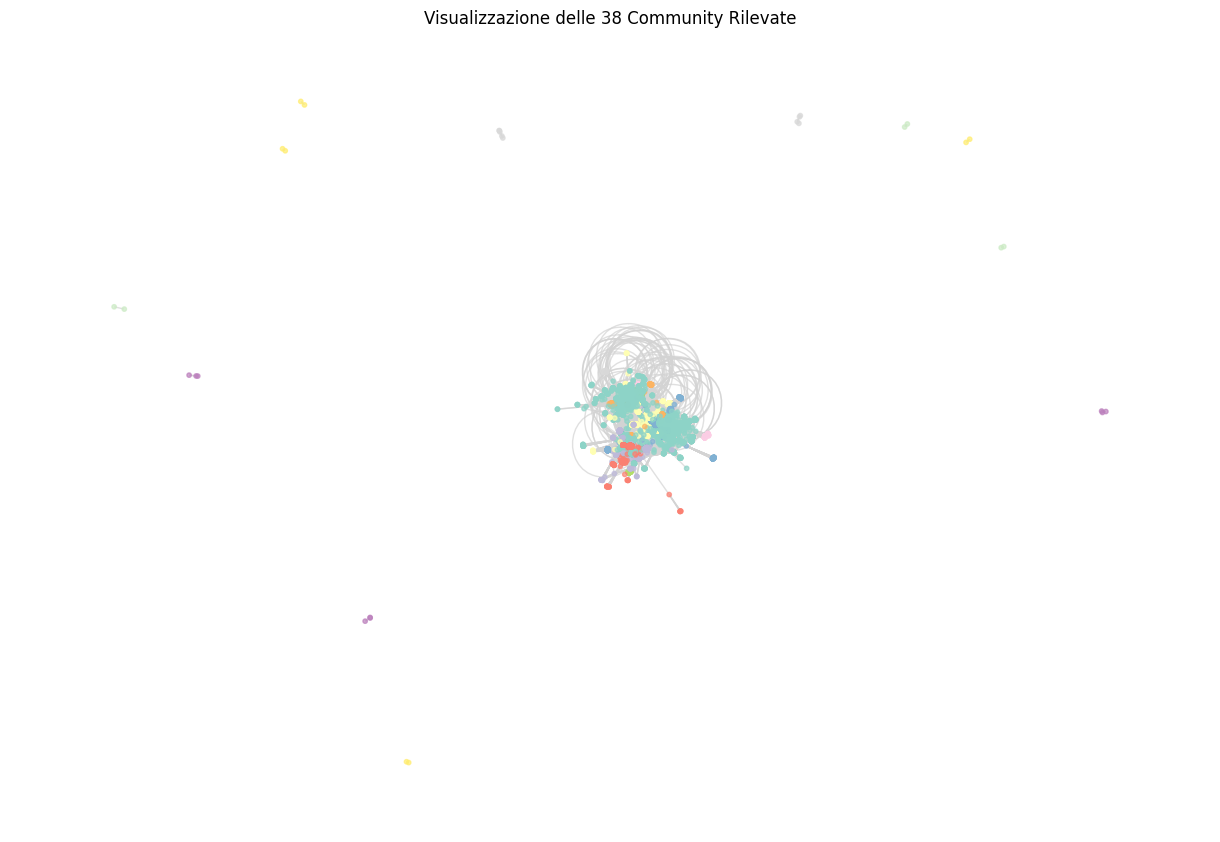

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

# Calcolo community
communities = list(greedy_modularity_communities(G))
num_communities = len(communities)

# Mappa utente → community
node_to_community = {}
for i, community in enumerate(communities):
    for node in community:
        node_to_community[node] = i

# Attribuisci i colori per visualizzazione
colors = [node_to_community[node] for node in G.nodes()]

# Visualizza il grafo con i colori di community
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=10, node_color=colors, cmap=plt.cm.Set3, edge_color='lightgray', alpha=0.7, with_labels=False)
plt.title(f"Visualizzazione delle {num_communities} Community Rilevate")
plt.tight_layout()
plt.savefig("community_detection_graph.png", dpi=300)
plt.show()


In [18]:
import networkx as nx
import pandas as pd
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

# Carica i dati del grafo (se necessario)
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcolo delle community
communities = list(greedy_modularity_communities(G))
num_communities = len(communities)

# Calcolo della modularità
modularity_value = modularity(G, communities)

# Trova la community più grande
largest_community = max(communities, key=len)
size_largest = len(largest_community)

# Stampa dei risultati
print(f"Numero di communities: {num_communities}")
print(f"Modularity: {modularity_value:.4f}")
print(f"La community più grande è la #{communities.index(largest_community)} con {size_largest} nodi.")


Numero di communities: 38
Modularity: 0.8331
La community più grande è la #0 con 1002 nodi.


In [19]:
import networkx as nx
import pandas as pd

# Carica il grafo
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Calcolo Eigenvector Centrality
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

# Ordina i risultati
df_eigen = pd.DataFrame(eigenvector.items(), columns=["user", "eigenvector_centrality"])
df_eigen = df_eigen.sort_values(by="eigenvector_centrality", ascending=False)

# Salva i risultati
df_eigen.to_csv("eigenvector_centrality_reddit.csv", index=False)

# Mostra top 10
print(df_eigen.head(10))


                    user  eigenvector_centrality
1554            Decronym                0.067961
1692           DeerKoden                0.067064
1782             superh0                0.066844
1594            EClarkee                0.066700
1639      ElectricGlider                0.066358
1407       SuperDerpHero                0.065891
1837     Peace_Is_Coming                0.065751
1651  The_Great_Squijibo                0.065743
1769            jwardell                0.065743
1580           malbecman                0.065295


Numero di community: 40
Modularità: 0.8710


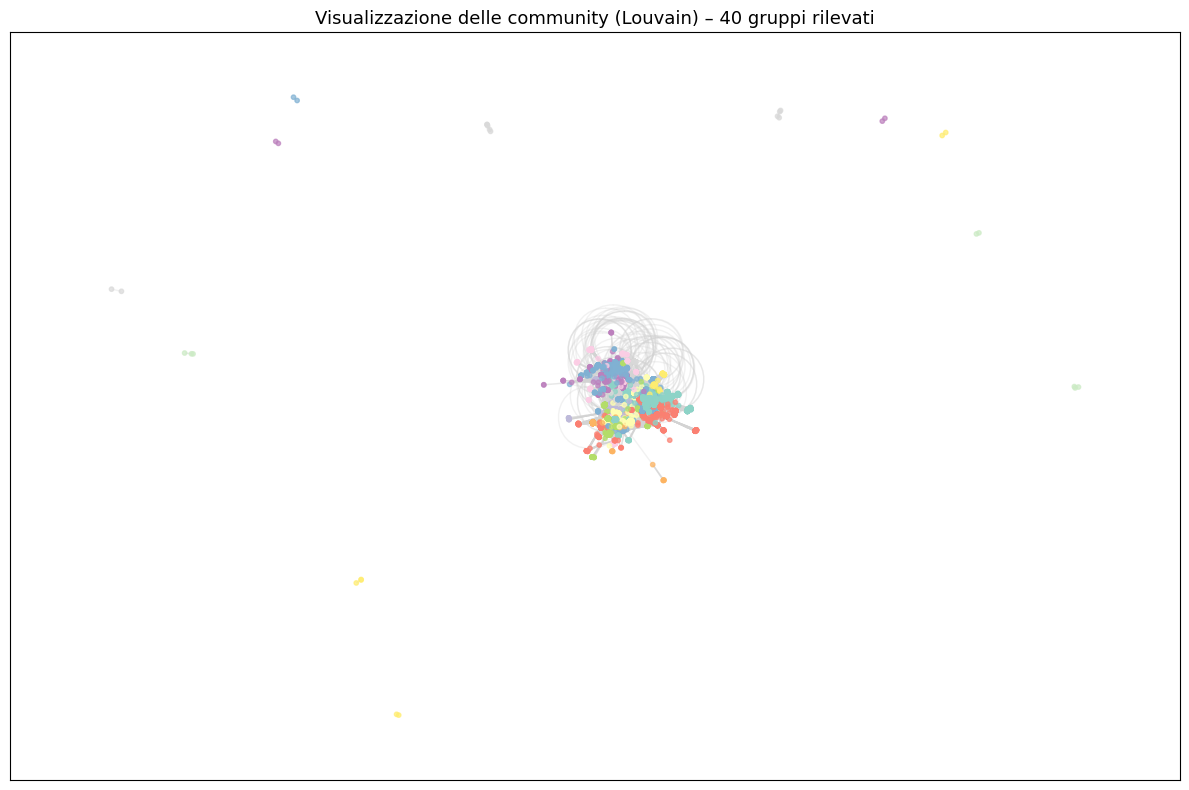

In [21]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain

# Carica grafo
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# Louvain: Calcolo delle community
partition = community_louvain.best_partition(G, weight='weight')
modularity_value = community_louvain.modularity(partition, G, weight='weight')
num_communities = len(set(partition.values()))

print(f"Numero di community: {num_communities}")
print(f"Modularità: {modularity_value:.4f}")

# Colori dei nodi per grafico
colors = [partition[node] for node in G.nodes()]

# Visualizzazione grafo
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=10, node_color=colors, cmap=plt.cm.Set3, alpha=0.7)
nx.draw_networkx_edges(G, pos, edge_color="lightgray", alpha=0.3)
plt.title(f"Visualizzazione delle community (Louvain) – {num_communities} gruppi rilevati", fontsize=13)
plt.tight_layout()
plt.savefig("louvain_community_graph.png", dpi=300)
plt.show()


In [22]:
# Isola la community 0
community_0_nodes = [node for node, comm in partition.items() if comm == 0]
G_sub = G.subgraph(community_0_nodes).copy()

# Info base
print(f"Nodi: {G_sub.number_of_nodes()}")
print(f"Archi: {G_sub.number_of_edges()}")
print(f"Densità: {nx.density(G_sub):.4f}")

# Centralità (degree)
degree_centrality = nx.degree_centrality(G_sub)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 utenti per degree centrality:")
for user, score in top_degree:
    print(f"{user}: {score:.4f}")


Nodi: 257
Archi: 9934
Densità: 0.3020

Top 5 utenti per degree centrality:
Fidget08: 0.7695
natesully33: 0.6289
zipzoomramblafloon: 0.6250
iwerson2: 0.6250
eaglerulez: 0.5195


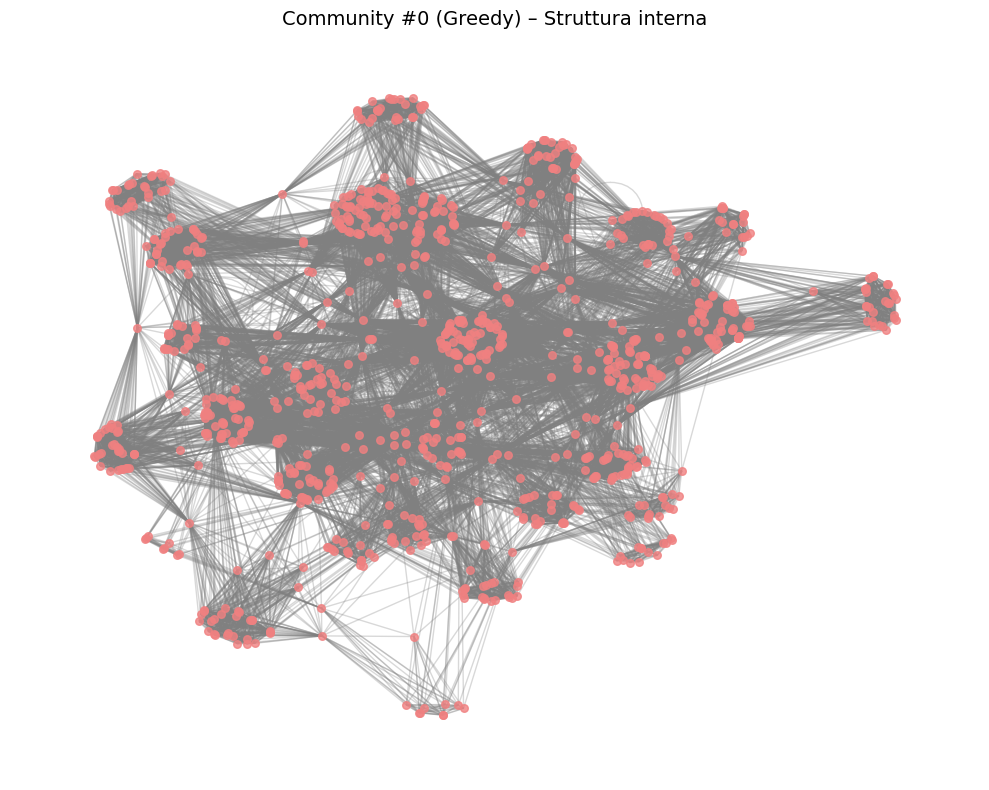

In [23]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

# 1. Carica il grafo
df_edges = pd.read_csv("edge_list.csv")
G = nx.Graph()
for _, row in df_edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

# 2. Calcola le community con Greedy
communities = list(greedy_modularity_communities(G))

# 3. Isola la community #0 (quella più grande, se vuoi puoi usare max(..., key=len))
community_0_nodes = list(communities[0])
G_sub = G.subgraph(community_0_nodes).copy()

# 4. Visualizzazione della community 0
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, seed=42)
nx.draw_networkx_nodes(G_sub, pos, node_size=30, node_color='lightcoral', alpha=0.8)
nx.draw_networkx_edges(G_sub, pos, edge_color='gray', alpha=0.3)
plt.title("Community #0 (Greedy) – Struttura interna", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("community_0_greedy_graph.png", dpi=300)  # ← salva immagine per slide
plt.show()


In [25]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Carica i commenti (modifica 'comments.csv' e 'text' se necessario)
df = pd.read_csv("comments.csv")  # ← metti qui il tuo file
analyzer = SentimentIntensityAnalyzer()

# Calcola il sentiment
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['text'].apply(get_sentiment)

# Conta e visualizza
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['green', 'gray', 'red'])
plt.title("Distribuzione del Sentiment nei commenti Reddit")
plt.xlabel("Sentiment")
plt.ylabel("Numero di commenti")
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=300)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'comments.csv'

In [26]:
import praw
import pandas as pd

# Config Reddit API (già fatto)
reddit = praw.Reddit(
    client_id="0PYPKuhHGg4cXmmjBFcW8Q",
    client_secret="5aXgtCQgesKU-5Yj2ItqQ2Jio3-okQ",
    user_agent="script:AutoProject:v1.0 (by u/DueInformation2883)"
)

# Specifica il subreddit che stai analizzando
subreddit = reddit.subreddit("electricvehicles")  # Cambia nome se necessario

# Estrai i commenti da più post
comments_data = []
for submission in subreddit.hot(limit=50):  # Puoi aumentare a 100 se vuoi
    submission.comments.replace_more(limit=0)
    for comment in submission.comments.list():
        comments_data.append(comment.body)

# Crea DataFrame e salva in CSV
df_comments = pd.DataFrame(comments_data, columns=["text"])
df_comments.dropna(inplace=True)  # rimuove eventuali righe vuote
df_comments.to_csv("comments.csv", index=False)
print(f"✅ Salvati {len(df_comments)} commenti in comments.csv")


✅ Salvati 3513 commenti in comments.csv


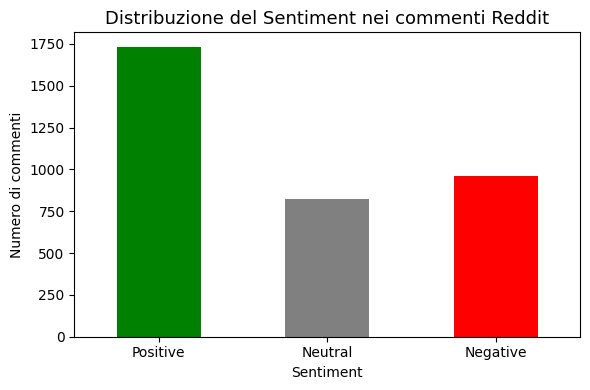

In [27]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Carica il CSV
df = pd.read_csv("comments.csv")  # Assicurati che sia nello stesso percorso

# Inizializza l'analizzatore
analyzer = SentimentIntensityAnalyzer()

# Funzione per classificare il sentiment
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Applica la funzione
df['sentiment'] = df['text'].apply(get_sentiment)

# Conta i risultati
sentiment_counts = df['sentiment'].value_counts().reindex(['Positive', 'Neutral', 'Negative'], fill_value=0)

# Grafico
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['green', 'gray', 'red'])
plt.title("Distribuzione del Sentiment nei commenti Reddit", fontsize=13)
plt.xlabel("Sentiment")
plt.ylabel("Numero di commenti")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=300)
plt.show()


In [28]:
import praw
import pandas as pd

# Configurazione API Reddit
reddit = praw.Reddit(
    client_id="0PYPKuhHGg4cXmmjBFcW8Q",
    client_secret="5aXgtCQgesKU-5Yj2ItqQ2Jio3-okQ",
    user_agent="script:AutoProject:v1.0 (by u/DueInformation2883)"
)

# Modelli e categorie
electric_models = ["Tesla Model 3", "Nissan Leaf", "Polestar 2"]
gas_models = ["BMW Serie 3", "Volkswagen Golf GTI", "Ford Focus ST"]
model_list = [(model, "elettrica") for model in electric_models] + [(model, "benzina") for model in gas_models]

subreddits = ["cars", "whatcarshouldIbuy", "TeslaMotors"]  # Puoi aggiungerne altri

# Estrazione commenti
comments_data = []

for model, tipo in model_list:
    for subreddit_name in subreddits:
        try:
            subreddit = reddit.subreddit(subreddit_name)
            print(f"Cercando '{model}' in r/{subreddit_name}...")
            for post in subreddit.search(model, limit=10):
                post.comments.replace_more(limit=0)
                for comment in post.comments:
                    if comment.author and comment.author.name != "AutoModerator":
                        comments_data.append({
                            "text": comment.body,
                            "model": model,
                            "tipo": tipo,
                            "subreddit": subreddit_name
                        })
        except Exception as e:
            print(f"Errore con {model} in r/{subreddit_name}: {e}")

# Salvataggio
df_comments = pd.DataFrame(comments_data)
df_comments.to_csv("comments_modelli.csv", index=False)
print(f"✅ Salvati {len(df_comments)} commenti in comments_modelli.csv")


Cercando 'Tesla Model 3' in r/cars...
Cercando 'Tesla Model 3' in r/whatcarshouldIbuy...
Cercando 'Tesla Model 3' in r/TeslaMotors...
Cercando 'Nissan Leaf' in r/cars...
Cercando 'Nissan Leaf' in r/whatcarshouldIbuy...
Cercando 'Nissan Leaf' in r/TeslaMotors...
Cercando 'Polestar 2' in r/cars...
Cercando 'Polestar 2' in r/whatcarshouldIbuy...
Cercando 'Polestar 2' in r/TeslaMotors...
Cercando 'BMW Serie 3' in r/cars...
Cercando 'BMW Serie 3' in r/whatcarshouldIbuy...
Cercando 'BMW Serie 3' in r/TeslaMotors...
Cercando 'Volkswagen Golf GTI' in r/cars...
Cercando 'Volkswagen Golf GTI' in r/whatcarshouldIbuy...
Cercando 'Volkswagen Golf GTI' in r/TeslaMotors...
Cercando 'Ford Focus ST' in r/cars...
Cercando 'Ford Focus ST' in r/whatcarshouldIbuy...
Cercando 'Ford Focus ST' in r/TeslaMotors...
✅ Salvati 6748 commenti in comments_modelli.csv


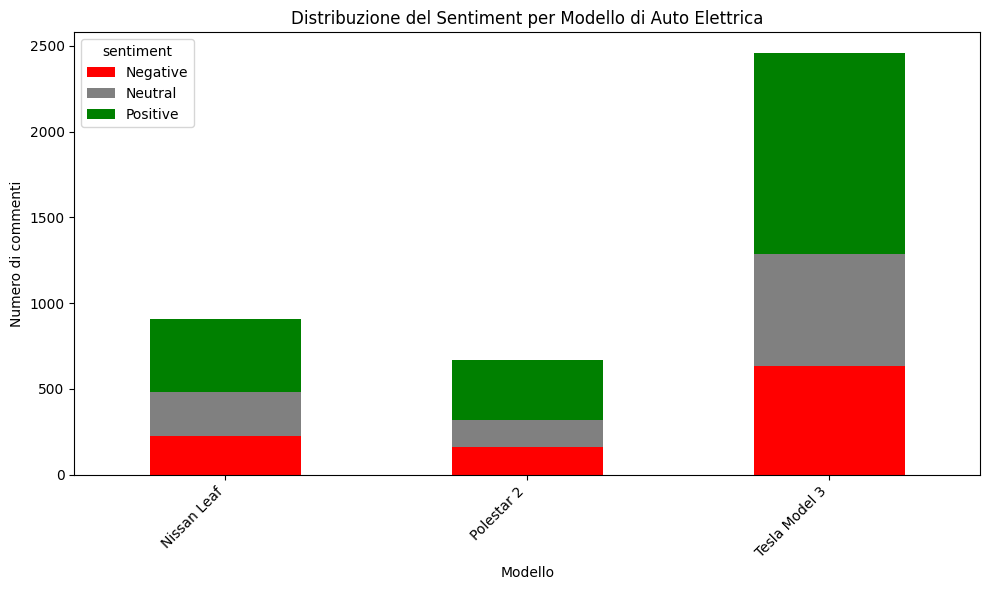

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Carica il file
df = pd.read_csv("comments_modelli.csv")

# Filtra le auto elettriche
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Inizializza l'analizzatore
analyzer = SentimentIntensityAnalyzer()

# Funzione per classificare il sentiment
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Applica il sentiment
df_elettriche["sentiment"] = df_elettriche["text"].apply(get_sentiment)

# Raggruppa per modello
sentiment_per_model = df_elettriche.groupby(["model", "sentiment"]).size().unstack(fill_value=0)

# Salva il CSV
sentiment_per_model.to_csv("sentiment_elettriche_risultati.csv")

# Grafico
sentiment_per_model.plot(kind='bar', stacked=True, color=['red', 'gray', 'green'], figsize=(10, 6))
plt.title("Distribuzione del Sentiment per Modello di Auto Elettrica")
plt.xlabel("Modello")
plt.ylabel("Numero di commenti")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("sentiment_elettriche.png", dpi=300)
plt.show()


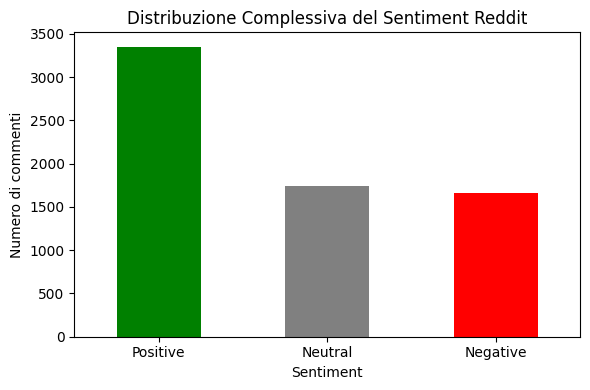

In [30]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Carica i dati completi
df = pd.read_csv("comments_modelli.csv")

# Analizza il sentiment
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df["sentiment"] = df["text"].apply(get_sentiment)

# Conteggio totale
sentiment_counts = df["sentiment"].value_counts().reindex(["Positive", "Neutral", "Negative"], fill_value=0)

# Grafico generale
colors = ['green', 'gray', 'red']
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=colors)
plt.title("Distribuzione Complessiva del Sentiment Reddit")
plt.xlabel("Sentiment")
plt.ylabel("Numero di commenti")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sentiment_totale.png", dpi=300)
plt.show()


In [31]:
import pandas as pd
import re
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Carica i commenti
df = pd.read_csv("comments_modelli.csv")
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Analisi del sentiment
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_elettriche["sentiment"] = df_elettriche["text"].apply(get_sentiment)
df_pos = df_elettriche[df_elettriche["sentiment"] == "Positive"]

# Preprocessing: rimozione stopword
stop_words = set(stopwords.words('english'))
words = []

for text in df_pos["text"]:
    tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())  # parole con almeno 3 lettere
    filtered = [w for w in tokens if w not in stop_words]
    words.extend(filtered)

# Mostra le 20 parole più frequenti
word_freq = Counter(words).most_common(20)
print(word_freq)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\feder\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


[('car', 850), ('tesla', 669), ('like', 606), ('model', 496), ('get', 370), ('would', 332), ('one', 306), ('cars', 305), ('range', 233), ('better', 231), ('good', 227), ('drive', 225), ('really', 215), ('much', 214), ('also', 199), ('leaf', 186), ('even', 184), ('new', 179), ('think', 178), ('people', 178)]


In [32]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Carica il CSV
df = pd.read_csv("comments_modelli.csv")

# Filtra i commenti delle auto elettriche
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Inizializza analizzatore
analyzer = SentimentIntensityAnalyzer()

# Calcola il compound score
df_elettriche["compound"] = df_elettriche["text"].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Statistiche
print("Media:", df_elettriche["compound"].mean())
print("Mediana:", df_elettriche["compound"].median())
print("Deviazione standard:", df_elettriche["compound"].std())
print("Valore massimo:", df_elettriche["compound"].max())
print("Valore minimo:", df_elettriche["compound"].min())


Media: 0.1525148946716233
Mediana: 0.0
Deviazione standard: 0.478554285523666
Valore massimo: 0.9986
Valore minimo: -0.9872


In [33]:
import praw
import pandas as pd

# Configura l'accesso a Reddit
reddit = praw.Reddit(
    client_id="0PYPKuhHGg4cXmmjBFcW8Q",
    client_secret="5aXgtCQgesKU-5Yj2ItqQ2Jio3-okQ",
    user_agent="script:AutoProject:v1.0 (by u/DueInformation2883)"
)

electric_models = ["Tesla Model 3", "Nissan Leaf", "Polestar 2"]
subreddits = ["cars", "whatcarshouldIbuy", "TeslaMotors"]

posts = []

for model in electric_models:
    for sub in subreddits:
        try:
            for post in reddit.subreddit(sub).search(model, sort="top", limit=10):
                posts.append({
                    "model": model,
                    "subreddit": sub,
                    "title": post.title,
                    "text": post.selftext,
                    "score": post.score,
                    "post_id": post.id,
                    "url": f"https://www.reddit.com{post.permalink}"
                })
        except Exception as e:
            print(f"Errore su {model} in r/{sub}: {e}")

# Salva i dati in CSV
df_posts = pd.DataFrame(posts)
df_posts.to_csv("top_posts_elettriche.csv", index=False)
print("✅ Post salvati in top_posts_elettriche.csv")


✅ Post salvati in top_posts_elettriche.csv


In [47]:
import praw
import pandas as pd

# Configura l'accesso a Reddit
reddit = praw.Reddit(
    client_id="0PYPKuhHGg4cXmmjBFcW8Q",
    client_secret="5aXgtCQgesKU-5Yj2ItqQ2Jio3-okQ",
    user_agent="script:AutoProject:v1.0 (by u/DueInformation2883)"
)

# Modelli a benzina e subreddit da cercare
benzina_models = ["BMW Serie 3", "Volkswagen GTI", "Ford Focus ST"]
subreddits = ["cars", "whatcarshouldIbuy", "BMW", "GolfGTI", "Ford"]

posts = []

# Cerca i post più votati per ciascun modello e subreddit
for model in benzina_models:
    for sub in subreddits:
        try:
            for post in reddit.subreddit(sub).search(model, sort="top", limit=10):
                posts.append({
                    "model": model,
                    "subreddit": sub,
                    "title": post.title,
                    "text": post.selftext,
                    "score": post.score,
                    "post_id": post.id,
                    "url": f"https://www.reddit.com{post.permalink}"
                })
        except Exception as e:
            print(f"❌ Errore su {model} in r/{sub}: {e}")

# Salva i risultati
df_posts = pd.DataFrame(posts)
df_posts.to_csv("top_posts_benzina.csv", index=False)
print("✅ Post salvati in top_posts_benzina.csv")


✅ Post salvati in top_posts_benzina.csv


MAE (Errore assoluto medio): 1019.82
RMSE (Errore quadratico medio): 2625.93


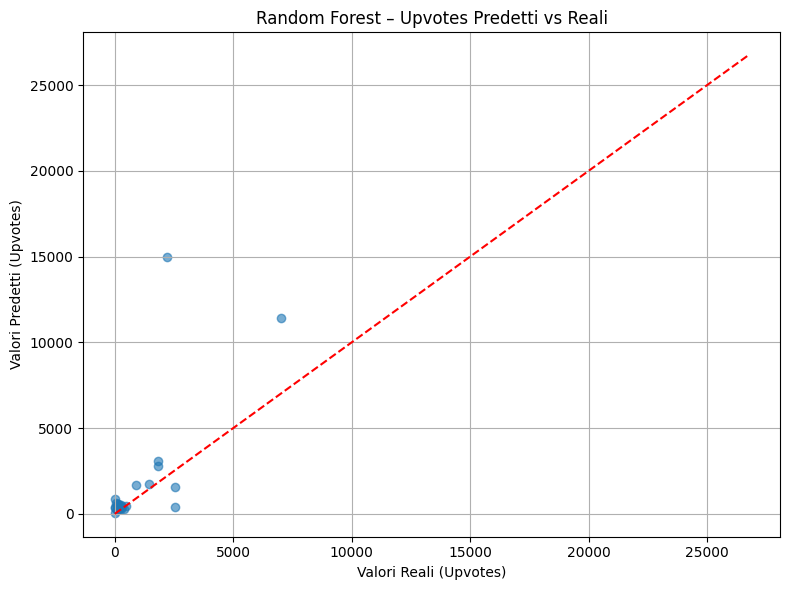

In [49]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 📥 Carica i dati
df1 = pd.read_csv("top_posts_elettriche.csv")
df2 = pd.read_csv("top_posts_benzina.csv")
df = pd.concat([df1, df2], ignore_index=True)

# 🔧 Pulizia
df.dropna(subset=["model", "title", "text", "score", "subreddit"], inplace=True)

# 🧠 Analisi del sentiment
analyzer = SentimentIntensityAnalyzer()
df["sentiment"] = df["text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])
df["text_length"] = df["text"].apply(lambda x: len(str(x)))

# 🎯 Variabili
X = df[["model", "subreddit", "sentiment", "text_length"]]
y = df["score"]

# 🔄 Preprocessing
categorical_features = ["model", "subreddit"]
numerical_features = ["sentiment", "text_length"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ("num", StandardScaler(), numerical_features)
])

# 🌲 Modello ML
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

# 🧪 Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🚀 Allenamento
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# 📊 Valutazione corretta
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE (Errore assoluto medio): {mae:.2f}")
print(f"RMSE (Errore quadratico medio): {rmse:.2f}")


# 📈 Grafico Predetto vs Reale
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Valori Reali (Upvotes)")
plt.ylabel("Valori Predetti (Upvotes)")
plt.title("Random Forest – Upvotes Predetti vs Reali")
plt.grid(True)
plt.tight_layout()
plt.savefig("upvotes_pred_vs_real.png")
plt.show()


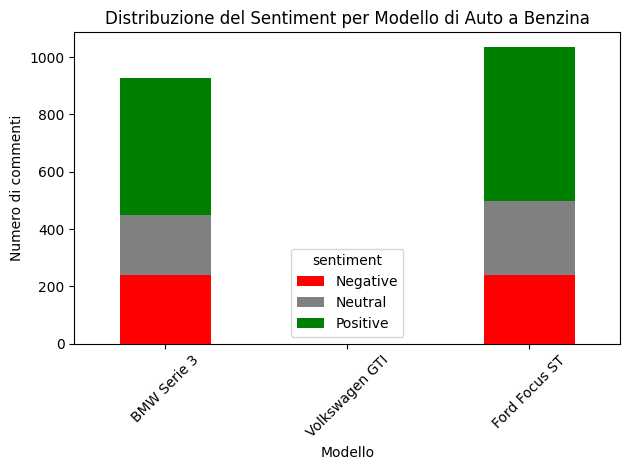

In [1]:
# Se non hai ancora installato la libreria, esegui questa riga:
# pip install vaderSentiment

import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Carica i dati
df = pd.read_csv("comments_modelli.csv")

# Filtro commenti auto a benzina
df_benzina = df[df["tipo"] == "benzina"].copy()

# Analisi del sentiment
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_benzina["sentiment"] = df_benzina["text"].apply(classify_sentiment)

# Conteggio dei sentiment per modello
sentiment_counts = df_benzina.groupby(["model", "sentiment"]).size().unstack(fill_value=0)

# Ordina i modelli se vuoi forzare un ordine specifico
ordered_models = ['BMW Serie 3', 'Volkswagen GTI', 'Ford Focus ST']
sentiment_counts = sentiment_counts.reindex(ordered_models)

# Plot
sentiment_counts[["Negative", "Neutral", "Positive"]].plot(
    kind="bar", stacked=True, color=["red", "gray", "green"]
)

plt.title("Distribuzione del Sentiment per Modello di Auto a Benzina")
plt.xlabel("Modello")
plt.ylabel("Numero di commenti")
plt.xticks(rotation=45)
plt.legend(title="sentiment")
plt.tight_layout()
plt.show()


In [1]:
# pip install vaderSentiment
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Carica i dati
df = pd.read_csv("comments_modelli.csv")

# Filtro solo commenti delle auto a benzina
df_benzina = df[df["tipo"] == "benzina"].copy()

# Correggi i nomi dei modelli per uniformità
df_benzina["model"] = df_benzina["model"].replace({
    "Volkswagen Golf GTI": "Volkswagen GTI"
})

# Sentiment analysis
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_benzina["sentiment"] = df_benzina["text"].apply(classify_sentiment)

# Conta i commenti per modello e sentiment
sentiment_counts = df_benzina.groupby(["model", "sentiment"]).size().unstack(fill_value=0)

# Ordina per nome modello
sentiment_counts = sentiment_counts.sort_index()

# Grafico
plot = sentiment_counts[["Negative", "Neutral", "Positive"]].plot(
    kind="bar", stacked=True, color=["red", "gray", "green"], figsize=(10, 6)
)

plt.title("Distribuzione del Sentiment per Modello di Auto a Benzina")
plt.xlabel("Modello")
plt.ylabel("Numero di commenti")
plt.xticks(rotation=45)
plt.legend(title="sentiment")
plt.tight_layout()

# Salva il grafico
plt.savefig("sentiment_benzina.png", dpi=300)
plt.close()

print("✅ Grafico salvato come 'sentiment_benzina2.png'")


✅ Grafico salvato come 'sentiment_benzina2.png'


count    2713.000000
mean        0.192493
std         0.490420
min        -0.982400
25%         0.000000
50%         0.102700
75%         0.620200
max         0.997900
Name: compound, dtype: float64


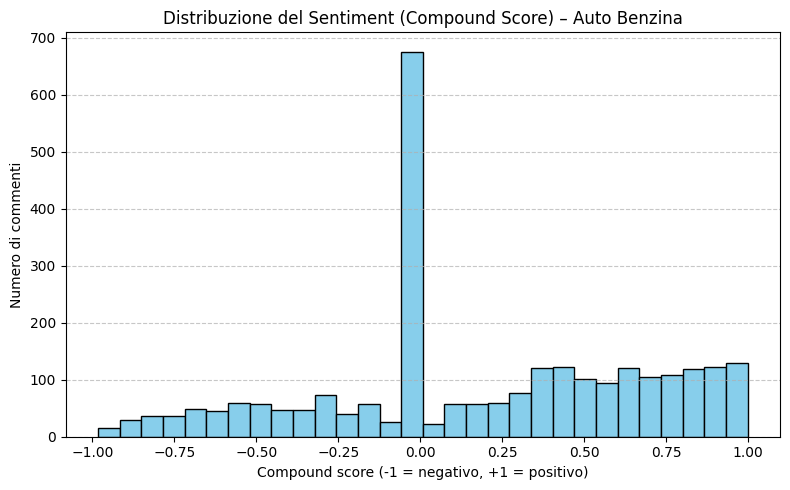

In [37]:

import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Caricamento dati
df = pd.read_csv("comments_modelli.csv")

# Filtro solo i commenti delle auto a benzina
df_benzina = df[df["tipo"] == "benzina"].copy()

# Correggo il nome del modello GTI
df_benzina["model"] = df_benzina["model"].replace({
    "Volkswagen Golf GTI": "Volkswagen GTI"
})

# Calcolo del compound score
analyzer = SentimentIntensityAnalyzer()
df_benzina["compound"] = df_benzina["text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

# Statistiche descrittive
print(df_benzina["compound"].describe())

# Istogramma
plt.figure(figsize=(8, 5))
plt.hist(df_benzina["compound"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribuzione del Sentiment (Compound Score) – Auto Benzina")
plt.xlabel("Compound score (-1 = negativo, +1 = positivo)")
plt.ylabel("Numero di commenti")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("compound_benzina.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Carica il CSV
df = pd.read_csv("comments_modelli.csv")

# Filtra i commenti delle auto elettriche
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Inizializza analizzatore
analyzer = SentimentIntensityAnalyzer()

# Calcola il compound score
df_elettriche["compound"] = df_elettriche["text"].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Statistiche
print("Media:", df_elettriche["compound"].mean())
print("Mediana:", df_elettriche["compound"].median())
print("Deviazione standard:", df_elettriche["compound"].std())
print("Valore massimo:", df_elettriche["compound"].max())
print("Valore minimo:", df_elettriche["compound"].min())


Media: 0.1525148946716233
Mediana: 0.0
Deviazione standard: 0.478554285523666
Valore massimo: 0.9986
Valore minimo: -0.9872


count    4035.000000
mean        0.152515
std         0.478554
min        -0.987200
25%        -0.051600
50%         0.000000
75%         0.551400
max         0.998600
Name: compound, dtype: float64


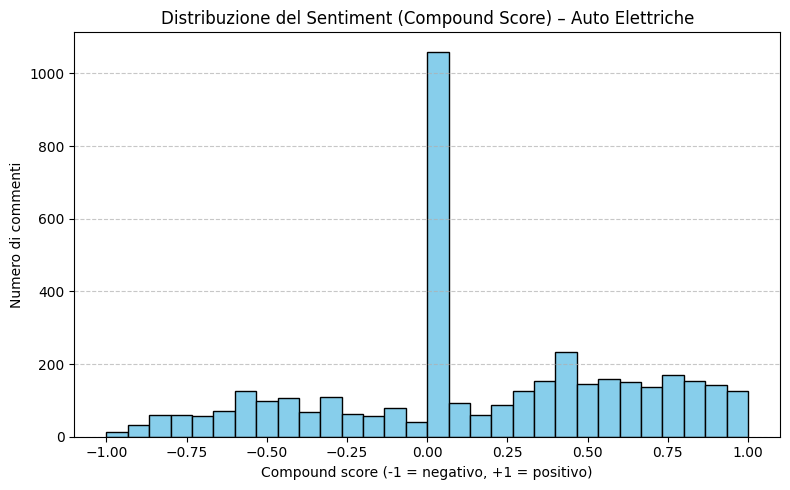

In [38]:
# pip install vaderSentiment
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Caricamento dati
df = pd.read_csv("comments_modelli.csv")

# Filtro solo commenti delle auto elettriche
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Calcolo del compound score
analyzer = SentimentIntensityAnalyzer()
df_elettriche["compound"] = df_elettriche["text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

# Statistiche descrittive
print(df_elettriche["compound"].describe())

# Grafico corretto
plt.figure(figsize=(8, 5))
plt.hist(df_elettriche["compound"], bins=30, range=(-1, 1), color="skyblue", edgecolor="black")
plt.title("Distribuzione del Sentiment (Compound Score) – Auto Elettriche")
plt.xlabel("Compound score (-1 = negativo, +1 = positivo)")
plt.ylabel("Numero di commenti")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("compound_elettriche.png", dpi=300)
plt.show()


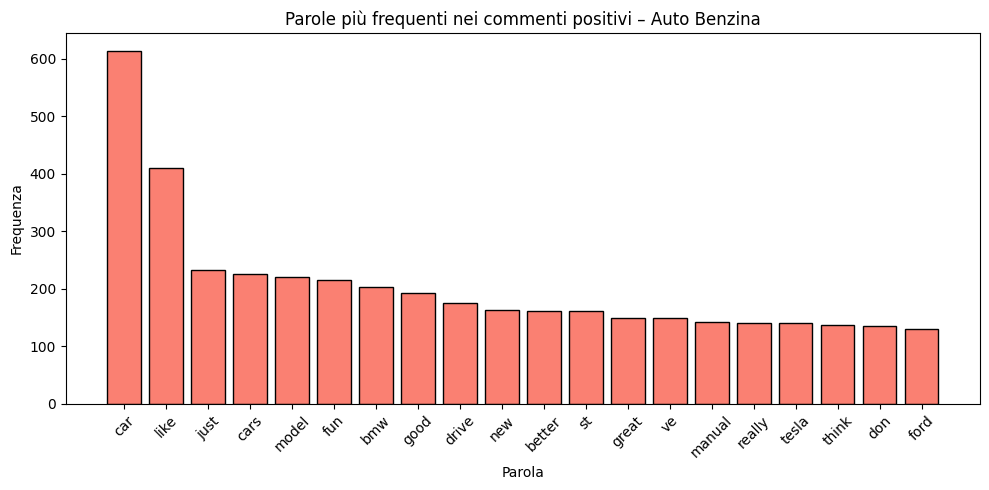

      word  frequency
2      car        614
11    like        410
10    just        233
3     cars        226
13   model        220
7      fun        216
1      bmw        203
8     good        192
5    drive        176
14     new        163
0   better        161
16      st        161
9    great        150
19      ve        150
12  manual        142
15  really        141
17   tesla        141
18   think        138
4      don        135
6     ford        131


In [41]:
# pip install vaderSentiment scikit-learn
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Carica i dati
df = pd.read_csv("comments_modelli.csv")

# Filtra le auto a benzina
df_benzina = df[df["tipo"] == "benzina"].copy()
df_benzina["model"] = df_benzina["model"].replace({
    "Volkswagen Golf GTI": "Volkswagen GTI"
})

# Calcola compound score
analyzer = SentimentIntensityAnalyzer()
df_benzina["compound"] = df_benzina["text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

# Filtra solo i commenti positivi
df_positivi = df_benzina[df_benzina["compound"] >= 0.05]

# Estrai parole più frequenti (escludi stopwords inglesi)
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df_positivi["text"])
words = vectorizer.get_feature_names_out()
frequenze = X.toarray().sum(axis=0)

# Crea DataFrame e ordina
df_freq = pd.DataFrame({'word': words, 'frequency': frequenze}).sort_values(by='frequency', ascending=False)

# Mostra graficamente
plt.figure(figsize=(10, 5))
plt.bar(df_freq['word'], df_freq['frequency'], color='salmon', edgecolor='black')
plt.title("Parole più frequenti nei commenti positivi – Auto Benzina")
plt.xlabel("Parola")
plt.ylabel("Frequenza")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lessico_benzina.png", dpi=300)
plt.show()

# Opzionale: stampa tabella
print(df_freq)


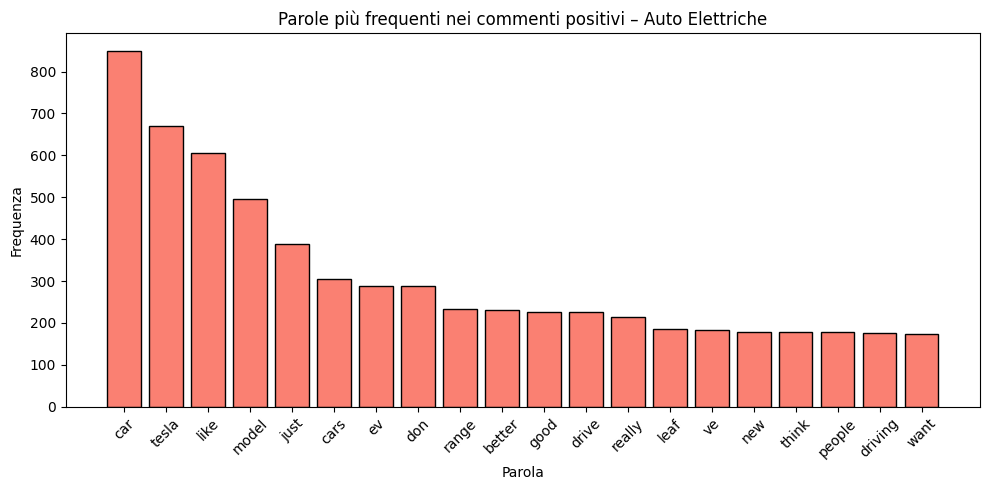

       word  frequency
1       car        850
16    tesla        669
10     like        606
11    model        496
8      just        388
2      cars        305
6        ev        288
3       don        287
14    range        233
0    better        231
7      good        227
4     drive        225
15   really        215
9      leaf        186
18       ve        184
12      new        179
17    think        178
13   people        178
5   driving        175
19     want        174


In [42]:
# pip install vaderSentiment scikit-learn
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Carica il dataset
df = pd.read_csv("comments_modelli.csv")

# Filtra solo le auto elettriche
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Calcola il compound score
analyzer = SentimentIntensityAnalyzer()
df_elettriche["compound"] = df_elettriche["text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

# Tieni solo i commenti positivi
df_pos = df_elettriche[df_elettriche["compound"] >= 0.05]

# Estrai parole più frequenti
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(df_pos["text"])
words = vectorizer.get_feature_names_out()
frequenze = X.toarray().sum(axis=0)

# Crea DataFrame e ordina
df_freq = pd.DataFrame({'word': words, 'frequency': frequenze}).sort_values(by='frequency', ascending=False)

# Grafico a barre (stile coerente con benzina)
plt.figure(figsize=(10, 5))
plt.bar(df_freq['word'], df_freq['frequency'], color='salmon', edgecolor='black')
plt.title("Parole più frequenti nei commenti positivi – Auto Elettriche")
plt.xlabel("Parola")
plt.ylabel("Frequenza")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lessico_elettriche.png", dpi=300)
plt.show()

# Optional: stampa tabella
print(df_freq)


In [43]:
import pandas as pd

# Carica il file
df = pd.read_csv("comments_modelli.csv")

# Filtra solo commenti sulle auto a benzina
df_benzina = df[df["tipo"] == "benzina"].copy()

# Rimuovi duplicati basandoti su modello + testo (opzionale ma utile)
df_benzina_unique = df_benzina.drop_duplicates(subset=["model", "text"])

# Raggruppa per modello e prendi i primi 10 "titoli" rappresentativi (simulati dal contenuto dei commenti)
top_samples = (
    df_benzina_unique
    .groupby("model")["text"]
    .apply(lambda x: x.head(10).tolist())
    .reset_index()
    .explode("text")
)

# Aggiungi subreddit per aiutarti nella ricerca
top_samples = top_samples.merge(df_benzina[["text", "subreddit"]], on="text", how="left").drop_duplicates()

# Salva per uso manuale
top_samples.to_csv("post_sample_benzina.csv", index=False)

# Mostra anteprima
print(top_samples.head(10))


         model                                               text subreddit
0  BMW Serie 3            This is gonna put r/cars in crisis mode      cars
1  BMW Serie 3  0.93 g of grip that's high crazy thing is a 20...      cars
2  BMW Serie 3  > The Altima outcornered not only the BMW 330i...      cars
3  BMW Serie 3                  This will definitely be on an ad.      cars
4  BMW Serie 3  That’s great, but peak corner Gs are not the s...      cars
5  BMW Serie 3  Gotta give credit where credit is due. Good jo...      cars
6  BMW Serie 3            Breaking news: run flats are horrible.       cars
7  BMW Serie 3  Hmm, this is curious. So the Nissan on all sea...      cars
8  BMW Serie 3  > It should be noted that the skidpad isn't an...      cars
9  BMW Serie 3  Hell, my Civic pulls 0.88g \n\n\nthats .01 off...      cars


In [46]:
import pandas as pd

# 🔧 Dati iniziali vuoti: puoi modificarli o aggiungerne altri
dati = [
    {
        "model": "BMW Serie 3",
        "title": "",
        "score": "",
        "url": ""
    },
    {
        "model": "Volkswagen GTI",
        "title": "",
        "score": "",
        "url": ""
    },
    {
        "model": "Ford Focus ST",
        "title": "",
        "score": "",
        "url": ""
    }
]

# 🔹 Crea DataFrame
df = pd.DataFrame(dati)

# 🔹 Salva come CSV da compilare
df.to_csv("top_posts_benzina.csv", index=False)

print("✅ File 'top_posts_benzina.csv' creato. Ora aprilo e inserisci titolo, score e URL per ogni modello.")


✅ File 'top_posts_benzina.csv' creato. Ora aprilo e inserisci titolo, score e URL per ogni modello.


In [ ]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Carica il CSV
df = pd.read_csv("comments_modelli.csv")

# Filtra i commenti delle auto elettriche
df_elettriche = df[df["tipo"] == "elettrica"].copy()

# Inizializza analizzatore
analyzer = SentimentIntensityAnalyzer()

# Calcola il compound score
df_elettriche["compound"] = df_elettriche["text"].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Statistiche
print("Media:", df_elettriche["compound"].mean())
print("Mediana:", df_elettriche["compound"].median())
print("Deviazione standard:", df_elettriche["compound"].std())
print("Valore massimo:", df_elettriche["compound"].max())
print("Valore minimo:", df_elettriche["compound"].min())


Media: 0.1525148946716233
Mediana: 0.0
Deviazione standard: 0.478554285523666
Valore massimo: 0.9986
Valore minimo: -0.9872
